## Solar Terrestrial Coupling Analysis

This notebook's purpose is to analyze a possible correlation between the number of sunspots registered and extreme solar events. By doing such analysis, it is viable to verify whether Solar Photospheric Activity (sunspots) events are connected to intense Space Weather Events activity or not.
The project acts as a continuation to the last two. The data utilized was gathered from the NASA Space Weather Events Dataset and the Solar Influences Data Analysis Center.

## Code

In [16]:
import csv
import matplotlib.pyplot as plt

events = {}
spots = {}

with open("../data/space_weather_unified.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["begin_time"]:
            keys = "-".join(row["begin_time"].strip().split("-")[:2])
            events[keys] = events.get(keys, 0) + 1

with open("../data/SN_d_tot_V2.0.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=';')
    for row in reader:
        year = row[0].strip()
        month = row[1].strip().zfill(2)
        sunspots = float(row[4].strip())
        
        key = f"{year}-{month}"
        
        if key not in spots:
            spots[key] = []
        spots[key].append(sunspots)

    normalmonth = sorted([m for m in events if m in spots])
    
    y_events = [events[m] for m in normalmonth]
    y_spots = [sum(spots[m]) / len(spots[m]) for m in normalmonth]

Unlike the previous projects, the code utilized is not that simple. It consists of extracting the necessary data from the CSVs in NASA and SILSO's website and arranging them to fit into the same format to plot the graph properly. For this project, I prefered to use a twin axis graph for better understanding and visualization.

## Results

As previously mentioned, the graph displays two different metrics in the same chart. The bars represent the extreme solar events and the red line simbolizes the number of sunspots. Since I am not very proficient in Matplotlib, the syntax utilized was AI assisted

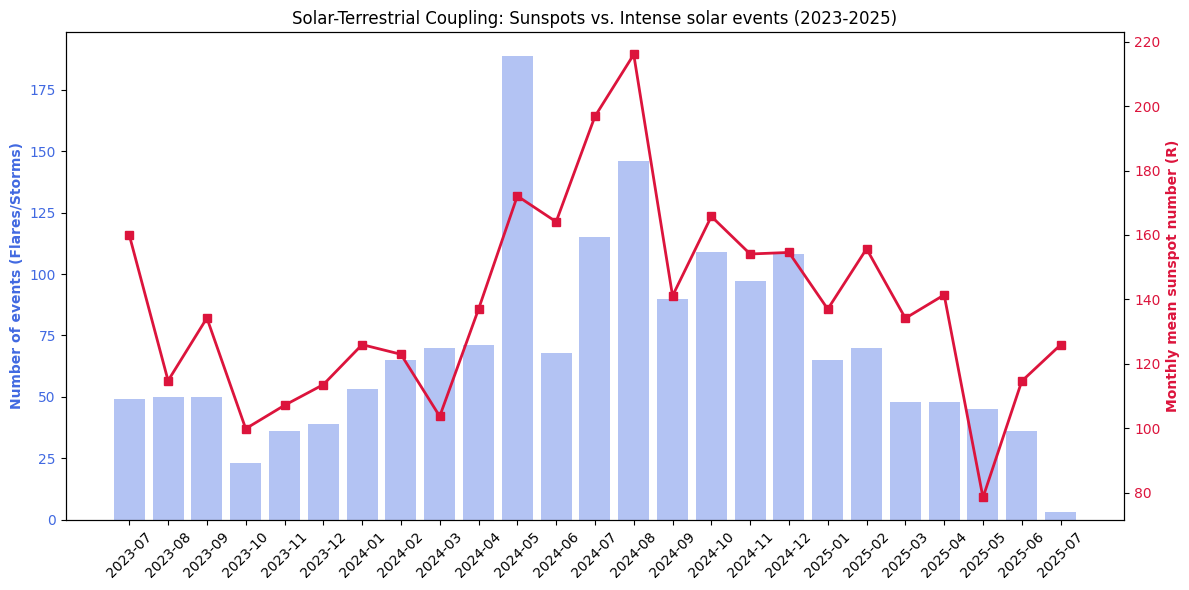

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(normalmonth, y_events, color='royalblue', alpha=0.4, label='Qtd. Eventos')
ax1.set_ylabel('Number of events (Flares/Storms)', color='royalblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='royalblue')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(normalmonth, y_spots, color='crimson', marker='s', linewidth=2, label='Average number of sunspots')
ax2.set_ylabel('Monthly mean sunspot number (R)', color='crimson', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title("Solar-Terrestrial Coupling: Sunspots vs. Intense solar events (2023-2025)")
fig.tight_layout()
plt.show()